# Arctic Sea Ice — G6-1.5K-SAI and G6-1.5K-HiLLA

Reads in sea ice concentration data from the G6-1.5K simulations and SSP2-4.5 baselines across multiple models, to plot some basic analyses, then calculates linear trend based time of emergence statistics for the SAI scenarios vs the background SSP2-4.5. 

1. Northern Hemisphere sea ice extent timeseries
2. Maps of mean sea ice concentration change (assessment period vs baseline)

**Models included:**
- CESM2-WACCM: HiLLA, SAI, SSP2-4.5 (ARISE/CMIP6 AWS store)
- UKESM1-1: HiLLA, SSP2-4.5 (SAI not available in bucket)
- MIROC-ES2H: HiLLA, SAI, SSP2-4.5 (baseline)
- E3SMv3: HiLLA, SSP2-4.5 (regridded first)

Alistair Duffey

In [27]:
import s3fs
import fsspec
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
import os
import boto3
import subprocess
import shutil
from urllib.parse import urlparse

sys.path.append('../shared/Code_examples/G6-1.5K_example/')
from Utils import weighted_annual_resample, set_time_to_center_of_bounds

import matplotlib
matplotlib.rcParams.update({'font.size': 13})

## File paths

In [28]:
# --- CESM2-WACCM ---
# ICEFRAC is on the standard f09 (0.9 x 1.25 deg) atmospheric lat/lon grid — no regridding needed

# SSP2-4.5 baseline: 10-member CESM2-WACCM-SSP245 runs, publicly available on AWS (anonymous access)
# Members 001-005 extend to 2100; members 006-010 end at 2069
ssp245_base = 'ncar-cesm2-arise/CESM2-WACCM-SSP245/'
_ssp245_end2 = {m: '210012' if int(m) <= 5 else '206912' for m in [f'{i:03d}' for i in range(1, 11)]}
cesm_ssp245_ice_files = [
    [f's3://{ssp245_base}b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{m}/atm/proc/tseries/month_1/'
     f'b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{m}.cam.h0.ICEFRAC.201501-206412.nc',
     f's3://{ssp245_base}b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{m}/atm/proc/tseries/month_1/'
     f'b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{m}.cam.h0.ICEFRAC.206501-{_ssp245_end2[m]}.nc']
    for m in _ssp245_end2
]

# G6-1.5K-HiLLA — r1 output is split into two time chunks; r2 and r3 are single files
cesm_HiLLA_ice_files = [
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.ICEFRAC.203501-203912.nc',
     's3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.ICEFRAC.204001-208412.nc'],
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.ICEFRAC.203501-208412.nc'],
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h0.ICEFRAC.203501-208412.nc'],
]

cesm_SAI_ice_files = [
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-SAI/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.001.cam.h0.ICEFRAC.203501-208412.nc'],
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-SAI/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.002.cam.h0.ICEFRAC.203501-208412.nc'],
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-SAI/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.003.cam.h0.ICEFRAC.203501-208412.nc'],
]

# --- UKESM1-1 ---
ukesm_HiLLA_ice_paths = [
    's3://reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r12i1p1f2/apm/SImon/siconca/',
    's3://reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r2i1p1f2/apm/SImon/siconca/',
    's3://reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r3i1p1f2/apm/SImon/siconca/',
]
ukesm_ssp245_ice_paths = [
    's3://reflective-persistent-prod-large/UKESM1-1/SSP245/r12i1p1f1/ap5/SImon/siconca/',
    's3://reflective-persistent-prod-large/UKESM1-1/SSP245/r2i1p1f1/ap5/SImon/siconca/',
    's3://reflective-persistent-prod-large/UKESM1-1/SSP245/r3i1p1f1/ap5/SImon/siconca/',
]

# --- MIROC-ES2H — all 10 members (r01–r10) ---
miroc_HiLLA_ice_files  = ['s3://reflective-persistent-prod-large/MIROC-ES2H/G6-1.5K-HiLLA/Omon/siconc_G6-1.5K-HiLLA_r{:02d}.nc'.format(i) for i in range(1, 11)]
miroc_SAI_ice_files    = ['s3://reflective-persistent-prod-large/MIROC-ES2H/G6-1.5K-SAI/Mon/SeaIce_G6-1.5K-SAI_r{:02d}.nc'.format(i) for i in range(1, 11)]
miroc_ssp245_ice_files = ['s3://reflective-persistent-prod-large/MIROC-ES2H/G6-1.5K-HiLLA/Omon/siconc_baseline_r{:02d}.nc'.format(i) for i in range(1, 11)]

# --- E3SMv3 ---
# Raw ICEFRAC is on native ne30pg2 grid — must be regridded first (see regridding cell below).
# Regridded output is written to reflective-persistent-prod; paths below are the read-back locations.
_E3SM_DEST = 'reflective-persistent-prod'
_e3sm_src_base = 's3://reflective-persistent-prod-large/E3SMv3/G6-1.5K-HiLLA'
_e3sm_gn_dir   = 'Amon/ICEFRAC/gn/13112025'

e3sm_regrid_jobs = [
    # (source_s3_dir,                                                          member, scenario)
    (f'{_e3sm_src_base}/v3.LR.ssp245.g6_hilla.sai.0101/{_e3sm_gn_dir}/', 'r1', 'G6-1.5K-HiLLA'),
    (f'{_e3sm_src_base}/v3.LR.ssp245.g6_hilla.sai.0151/{_e3sm_gn_dir}/', 'r2', 'G6-1.5K-HiLLA'),
    (f'{_e3sm_src_base}/v3.LR.ssp245.g6_hilla.sai.0201/{_e3sm_gn_dir}/', 'r3', 'G6-1.5K-HiLLA'),
    (f'{_e3sm_src_base}/v3.LR.ssp245_0101/{_e3sm_gn_dir}/',               'r1', 'SSP245'),
    (f'{_e3sm_src_base}/v3.LR.ssp245_0151/{_e3sm_gn_dir}/',               'r2', 'SSP245'),
    (f'{_e3sm_src_base}/v3.LR.ssp245_0201/{_e3sm_gn_dir}/',               'r3', 'SSP245'),
]

# Regridded single-file paths per member (written by the regridding cell)
e3sm_HiLLA_ice_files  = [[f's3://{_E3SM_DEST}/alistairduffey/E3SMv3/G6-1.5K-HiLLA/{r}/ICEFRAC/ICEFRAC_combined.nc'] for r in ['r1','r2','r3']]
e3sm_ssp245_ice_files = [[f's3://{_E3SM_DEST}/alistairduffey/E3SMv3/SSP245/{r}/ICEFRAC/ICEFRAC_combined.nc']         for r in ['r1','r2','r3']]


## Read in data

All sea ice concentration data is normalised to a common `siconc` variable in units of % (0–100).
CESM `ICEFRAC` is a fraction (0–1), so is multiplied by 100 on load.
The MIROC SAI files use a `SeaIce` filename prefix — the internal variable name is checked on first load.

In [29]:
def read_ice_from_file_list(file_list_of_lists, rename_var=None, scale=1.0, open_kwargs=None):
    """Read sea ice data for multiple members, each member given as a list of file paths.

    file_list_of_lists : list of lists — outer index = member, inner = file chunks
    rename_var         : variable name in file to rename to 'siconc'
    scale              : multiply data by this factor (use 100 to convert 0-1 fraction to %)
    open_kwargs        : extra kwargs passed to fsspec.open (e.g. {'anon': True} for public buckets)
    """
    if open_kwargs is None:
        open_kwargs = {}
    ds_list = []
    for member_files in file_list_of_lists:
        file_objects = [fsspec.open(f, mode='rb', **open_kwargs) for f in member_files]
        ds = xr.open_mfdataset([f.open() for f in file_objects],
                               combine='nested', concat_dim='time', chunks={}).load()
        # drop any duplicate time steps (e.g. overlap files)
        _, idx = np.unique(ds.time, return_index=True)
        ds = ds.isel(time=idx)
        if rename_var and rename_var in ds:
            ds = ds.rename({rename_var: 'siconc'})
        if scale != 1.0:
            ds['siconc'] = ds['siconc'] * scale
        ds_list.append(ds)
    return ds_list


def read_ice_from_directory_paths(path_list, rename_var=None, scale=1.0, time_slice=None):
    """Read sea ice data where each member lives in a directory of .nc files (e.g. UKESM)."""
    ds_list = []
    for path in path_list:
        files = fsspec.open_files(f"{path}*.nc", mode='rb')
        ds = xr.open_mfdataset([f.open() for f in files],
                               combine='nested', concat_dim='time', chunks={}).load()
        # drop any duplicate time steps (e.g. overlap files)
        _, idx = np.unique(ds.time, return_index=True)
        ds = ds.isel(time=idx)
        if rename_var and rename_var in ds:
            ds = ds.rename({rename_var: 'siconc'})
        if scale != 1.0:
            ds['siconc'] = ds['siconc'] * scale
        if time_slice:
            ds = ds.sel(time=slice(*time_slice))
        ds_list.append(ds)
    return ds_list

In [30]:
## CESM2-WACCM
# time_bounds gives the true start/end of each monthly interval;
# set the time coordinate to the midpoint of each interval
cesm_HiLLA_ice = read_ice_from_file_list(cesm_HiLLA_ice_files, rename_var='ICEFRAC', scale=100.0)
cesm_SAI_ice   = read_ice_from_file_list(cesm_SAI_ice_files,   rename_var='ICEFRAC', scale=100.0)

cesm_HiLLA_ice = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in cesm_HiLLA_ice]
cesm_SAI_ice   = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in cesm_SAI_ice]

In [31]:
## UKESM1-1
# HiLLA runs start 2034; select 2035 onwards to match other models
ukesm_HiLLA_ice  = read_ice_from_directory_paths(ukesm_HiLLA_ice_paths, rename_var='siconca',
                                                  time_slice=('2035', '2084'))
ukesm_ssp245_ice = read_ice_from_directory_paths(ukesm_ssp245_ice_paths, rename_var='siconca')

In [ ]:
## MIROC-ES2H
# The MIROC files use 'OCLATTPT256' as the latitude dimension name — rename to 'lat' on load
# MIROC siconc is stored as a fraction (0–1) not percentage — multiply by 100 on load
def read_miroc_ice(file_list):
    ds_list = []
    for f in file_list:
        with fsspec.open(f, mode='rb') as fobj:
            ds = xr.open_dataset(fobj, engine='h5netcdf', chunks={}).load()
        lat_dim = [d for d in ds.dims if d not in ('lon', 'time')]
        if lat_dim and lat_dim[0] != 'lat':
            ds = ds.rename({lat_dim[0]: 'lat'})
        # convert fraction → %
        for var in ds.data_vars:
            if 'ice' in var.lower() or 'conc' in var.lower() or var == 'SeaIce':
                ds[var] = ds[var] * 100.0
        ds_list.append(ds)
    return ds_list

miroc_HiLLA_ice  = read_miroc_ice(miroc_HiLLA_ice_files)
miroc_ssp245_ice = read_miroc_ice(miroc_ssp245_ice_files)

# SAI files use a different internal variable name — check before loading
with fsspec.open(miroc_SAI_ice_files[0], mode='rb') as f:
    _ds_check = xr.open_dataset(f, engine='h5netcdf')
    miroc_sai_var = [v for v in _ds_check.data_vars if 'ice' in v.lower() or 'conc' in v.lower()][0]
    print('MIROC SAI internal variable name:', miroc_sai_var)

miroc_SAI_ice = read_miroc_ice(miroc_SAI_ice_files)
if miroc_sai_var != 'siconc':
    miroc_SAI_ice = [ds.rename({miroc_sai_var: 'siconc'}) for ds in miroc_SAI_ice]

In [33]:
## CESM2-WACCM SSP2-4.5 — CESM2-WACCM-SSP245 runs (10 members, public AWS bucket)
# anon=True for public access; files span 2015–2100 across two time chunks per member
cesm_ssp245_ice = read_ice_from_file_list(
    cesm_ssp245_ice_files,
    rename_var='ICEFRAC',
    scale=100.0,
    open_kwargs={'anon': True}
)

# correct time values to centre of bounds:
cesm_ssp245_ice   = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in cesm_ssp245_ice]
print(f'Loaded {len(cesm_ssp245_ice)} CESM SSP2-4.5 members, time: {cesm_ssp245_ice[0].time.values[[0, -1]]}')

Loaded 10 CESM SSP2-4.5 members, time: [cftime.DatetimeNoLeap(2015, 1, 16, 12, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2100, 12, 16, 12, 0, 0, 0, has_year_zero=True)]


## E3SMv3 — regrid ICEFRAC from ne30pg2 → 1°×1° lat/lon

Downloads raw files from S3, regrids with `ncremap`, combines time chunks into one file per member, and uploads to `reflective-persistent-prod`. **Already-processed members are skipped** — safe to re-run.

In [34]:
MAP_FILE  = '../shared/Data/E3SM_maps/map_ne30pg2_to_cmip6_180x360_aave.20200201.nc'
LOCAL_WORK = './e3sm_icefrac_regrid_tmp'
s3_client  = boto3.client('s3')

def run_ncremap(input_path, output_path, map_file):
    subprocess.run(['ncremap', '-i', input_path, '-m', map_file, '-o', output_path],
                   check=True, capture_output=True, text=True)

os.makedirs(LOCAL_WORK, exist_ok=True)

for src_url, member, scenario in e3sm_regrid_jobs:
    dest_key = f'alistairduffey/E3SMv3/{scenario}/{member}/ICEFRAC/ICEFRAC_combined.nc'

    # skip if already uploaded
    try:
        s3_client.head_object(Bucket=_E3SM_DEST, Key=dest_key)
        print(f'  {scenario}/{member}: already exists — skipping')
        continue
    except s3_client.exceptions.ClientError:
        pass

    parsed     = urlparse(src_url)
    src_bucket = parsed.netloc
    src_prefix = parsed.path.lstrip('/')
    work_dir   = os.path.join(LOCAL_WORK, scenario, member)
    raw_dir    = os.path.join(work_dir, 'raw')
    regrid_dir = os.path.join(work_dir, 'regridded')
    os.makedirs(raw_dir, exist_ok=True)
    os.makedirs(regrid_dir, exist_ok=True)

    print(f'\n>>> {scenario}/{member}')
    response = s3_client.list_objects_v2(Bucket=src_bucket, Prefix=src_prefix)
    for obj in response.get('Contents', []):
        key = obj['Key']
        if not key.endswith('.nc'):
            continue
        fname      = os.path.basename(key)
        raw_path   = os.path.join(raw_dir, fname)
        regrid_path = os.path.join(regrid_dir, f'regridded_{fname}')
        print(f'  Downloading: {fname}')
        s3_client.download_file(src_bucket, key, raw_path)
        print(f'  Regridding:  {fname}')
        run_ncremap(raw_path, regrid_path, MAP_FILE)
        os.remove(raw_path)

    # combine all time chunks into one file
    combined_path = os.path.join(work_dir, 'ICEFRAC_combined.nc')
    ds = xr.open_mfdataset(f'{regrid_dir}/*.nc', combine='by_coords')
    ds.to_netcdf(combined_path)
    ds.close()

    # upload and verify
    print(f'  Uploading to s3://{_E3SM_DEST}/{dest_key}')
    s3_client.upload_file(combined_path, _E3SM_DEST, dest_key)
    local_sz = os.path.getsize(combined_path)
    s3_sz    = s3_client.head_object(Bucket=_E3SM_DEST, Key=dest_key)['ContentLength']
    assert local_sz == s3_sz, f'Size mismatch: local={local_sz}, s3={s3_sz}'
    print(f'  Verified ({s3_sz:,} bytes)')

    shutil.rmtree(work_dir)

shutil.rmtree(LOCAL_WORK, ignore_errors=True)
print('\nDone.')

  G6-1.5K-HiLLA/r1: already exists — skipping
  G6-1.5K-HiLLA/r2: already exists — skipping
  G6-1.5K-HiLLA/r3: already exists — skipping
  SSP245/r1: already exists — skipping
  SSP245/r2: already exists — skipping
  SSP245/r3: already exists — skipping

Done.


In [35]:
## E3SMv3 — read regridded ICEFRAC from S3 (fraction 0–1 → scale ×100 to get %)
e3sm_HiLLA_ice  = read_ice_from_file_list(e3sm_HiLLA_ice_files,  rename_var='ICEFRAC', scale=100.0)
e3sm_ssp245_ice = read_ice_from_file_list(e3sm_ssp245_ice_files, rename_var='ICEFRAC', scale=100.0)
print(f'E3SM HiLLA:  {len(e3sm_HiLLA_ice)} members, time: {e3sm_HiLLA_ice[0].time.values[[0,-1]]}')
print(f'E3SM SSP245: {len(e3sm_ssp245_ice)} members, time: {e3sm_ssp245_ice[0].time.values[[0,-1]]}')

## also correct time values to centre of bounds:
e3sm_HiLLA_ice = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in e3sm_HiLLA_ice]
e3sm_ssp245_ice   = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in e3sm_ssp245_ice]

E3SM HiLLA:  3 members, time: [cftime.DatetimeNoLeap(2035, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2085, 1, 1, 0, 0, 0, 0, has_year_zero=True)]
E3SM SSP245: 3 members, time: [cftime.DatetimeNoLeap(2015, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2085, 1, 1, 0, 0, 0, 0, has_year_zero=True)]


## Sea ice extent timeseries

NH sea ice area = fraction * grid cell area

Grid cell area is computed analytically from lat/lon coordinates - to do, read in grid cell area data directly (don't have this to hand for the ocean grids). 

In [36]:
R_EARTH = 6.371e6  # metres

def compute_cell_area(lat, lon):
    """Return a 2D DataArray of grid cell areas (m²) for a regular lat/lon grid."""
    dlat = np.deg2rad(np.abs(float(lat[1] - lat[0])))
    dlon = np.deg2rad(np.abs(float(lon[1] - lon[0])))
    cos_lat = np.cos(np.deg2rad(lat))
    area = R_EARTH**2 * cos_lat * dlat * dlon
    return area.expand_dims({'lon': len(lon)}, axis=1)  # m²


def _trim_partial_years(da):
    """Drop any year at the start/end of a monthly timeseries that is not complete (12 months)."""
    if da.time.dt.month.values[0] != 1:
        da = da.sel(time=da.time.dt.year >= int(da.time.dt.year.values[0]) + 1)
    if da.time.dt.month.values[-1] != 12:
        da = da.sel(time=da.time.dt.year <= int(da.time.dt.year.values[-1]) - 1)
    return da


def sia_timeseries(ds_list, month=None, lat_name='lat', lon_name='lon', lat_min=0.0):
    """NH sea ice area (10⁶ km²) timeseries.

    month=None → calendar-weighted annual mean
    month=int  → specific month only (e.g. 9=September, 3=March)
    """
    out = []
    for ds in ds_list:
        da = ds['siconc']
        if 'latitude' in da.dims:
            da = da.rename({'latitude': 'lat', 'longitude': 'lon'})
        da_nh = da.sel(**{lat_name: slice(lat_min, 90)})
        area  = compute_cell_area(da_nh[lat_name], da_nh[lon_name])
        sia   = ((da_nh / 100.0) * area).sum([lat_name, lon_name]) / 1e12  # 10⁶ km²

        # remove any partial year at the start or end before aggregating
        sia = _trim_partial_years(sia)

        if month is not None:
            ts = sia.sel(time=sia.time.dt.month == month)
            ts = ts.assign_coords(time=ts.time.dt.year)
        else:
            # calendar-weighted annual mean (only complete years remain after trim)
            wgt = sia.time.dt.days_in_month.astype(float)
            ts  = (sia * wgt).resample(time='YS').sum() / wgt.resample(time='YS').sum()
            ts  = ts.assign_coords(time=ts.time.dt.year)
        out.append(ts)
    return out

In [37]:
#miroc_ssp245_ice[0].isel(time=0).siconc.plot()

In [38]:
## Compute September, March, and annual mean NH sea ice area for all models/scenarios

models = ['CESM2-WACCM', 'UKESM1-1', 'MIROC-ES2H', 'E3SMv3']

def _build_sia_dict(month):
    return {
        'CESM2-WACCM': {
            'SSP2-4.5':      sia_timeseries(cesm_ssp245_ice,  month=month),
            'G6-1.5K-SAI':   sia_timeseries(cesm_SAI_ice,    month=month),
            'G6-1.5K-HiLLA': sia_timeseries(cesm_HiLLA_ice,  month=month),
        },
        'UKESM1-1': {
            'SSP2-4.5':      sia_timeseries(ukesm_ssp245_ice, month=month),
            'G6-1.5K-HiLLA': sia_timeseries(ukesm_HiLLA_ice, month=month),
        },
        'MIROC-ES2H': {
            'SSP2-4.5':      sia_timeseries(miroc_ssp245_ice, month=month),
            'G6-1.5K-SAI':   sia_timeseries(miroc_SAI_ice,   month=month),
            'G6-1.5K-HiLLA': sia_timeseries(miroc_HiLLA_ice, month=month),
        },
        'E3SMv3': {
            'SSP2-4.5':      sia_timeseries(e3sm_ssp245_ice,  month=month),
            'G6-1.5K-HiLLA': sia_timeseries(e3sm_HiLLA_ice,  month=month),
        },
    }

sep_sia_dict = _build_sia_dict(month=9)   # September
mar_sia_dict = _build_sia_dict(month=3)   # March
ann_sia_dict = _build_sia_dict(month=None) # annual mean

## Mean sea ice concentration maps

Time-mean `siconc` over the assessment period (2065–2084) for each scenario,
and anomaly relative to the SSP2-4.5 baseline (2020–2039).

In [39]:
baseline_years   = ('2020', '2039')
assessment_years = ('2065', '2084')

def ensemble_mean_map(ds_list, t_range):
    """Return ensemble-mean, time-mean siconc map over t_range (tuple of str years)."""
    maps = []
    for ds in ds_list:
        da = ds['siconc']
        if 'latitude' in da.dims:
            da = da.rename({'latitude': 'lat', 'longitude': 'lon'})
        maps.append(da.sel(time=slice(*t_range)).mean('time'))
    return xr.concat(maps, dim='member').mean('member')


# SSP245 baseline maps
cesm_ssp245_map_baseline  = ensemble_mean_map(cesm_ssp245_ice,  baseline_years)
ukesm_ssp245_map_baseline = ensemble_mean_map(ukesm_ssp245_ice, baseline_years)
miroc_ssp245_map_baseline = ensemble_mean_map(miroc_ssp245_ice, baseline_years)
e3sm_ssp245_map_baseline  = ensemble_mean_map(e3sm_ssp245_ice,  baseline_years)

# assessment period maps
cesm_ssp245_map  = ensemble_mean_map(cesm_ssp245_ice,  assessment_years)
cesm_HiLLA_map   = ensemble_mean_map(cesm_HiLLA_ice,   assessment_years)
cesm_SAI_map     = ensemble_mean_map(cesm_SAI_ice,     assessment_years)
ukesm_ssp245_map = ensemble_mean_map(ukesm_ssp245_ice, assessment_years)
ukesm_HiLLA_map  = ensemble_mean_map(ukesm_HiLLA_ice,  assessment_years)
miroc_ssp245_map = ensemble_mean_map(miroc_ssp245_ice, assessment_years)
miroc_HiLLA_map  = ensemble_mean_map(miroc_HiLLA_ice,  assessment_years)
miroc_SAI_map    = ensemble_mean_map(miroc_SAI_ice,    assessment_years)
e3sm_ssp245_map  = ensemble_mean_map(e3sm_ssp245_ice,  assessment_years)
e3sm_HiLLA_map   = ensemble_mean_map(e3sm_HiLLA_ice,   assessment_years)

map_anom_dict = {
    'CESM2-WACCM': {
        'SSP2-4.5':      cesm_ssp245_map  - cesm_ssp245_map_baseline,
        'G6-1.5K-SAI':   cesm_SAI_map    - cesm_ssp245_map_baseline,
        'G6-1.5K-HiLLA': cesm_HiLLA_map  - cesm_ssp245_map_baseline,
    },
    'UKESM1-1': {
        'SSP2-4.5':      ukesm_ssp245_map - ukesm_ssp245_map_baseline,
        'G6-1.5K-HiLLA': ukesm_HiLLA_map - ukesm_ssp245_map_baseline,
    },
    'MIROC-ES2H': {
        'SSP2-4.5':      miroc_ssp245_map - miroc_ssp245_map_baseline,
        'G6-1.5K-SAI':   miroc_SAI_map   - miroc_ssp245_map_baseline,
        'G6-1.5K-HiLLA': miroc_HiLLA_map - miroc_ssp245_map_baseline,
    },
    'E3SMv3': {
        'SSP2-4.5':      e3sm_ssp245_map  - e3sm_ssp245_map_baseline,
        'G6-1.5K-HiLLA': e3sm_HiLLA_map  - e3sm_ssp245_map_baseline,
    },
}

## Plotting

In [40]:
colours = {
    'SSP2-4.5':           'gray',
    'SSP2-4.5_light':     'lightgray',
    'G6-1.5K-HiLLA':      'green',
    'G6-1.5K-HiLLA_light':'lightgreen',
    'G6-1.5K-SAI':        'purple',
    'G6-1.5K-SAI_light':  'plum',
}

In [49]:
import matplotlib
matplotlib.rcParams.update({'font.size': 15})

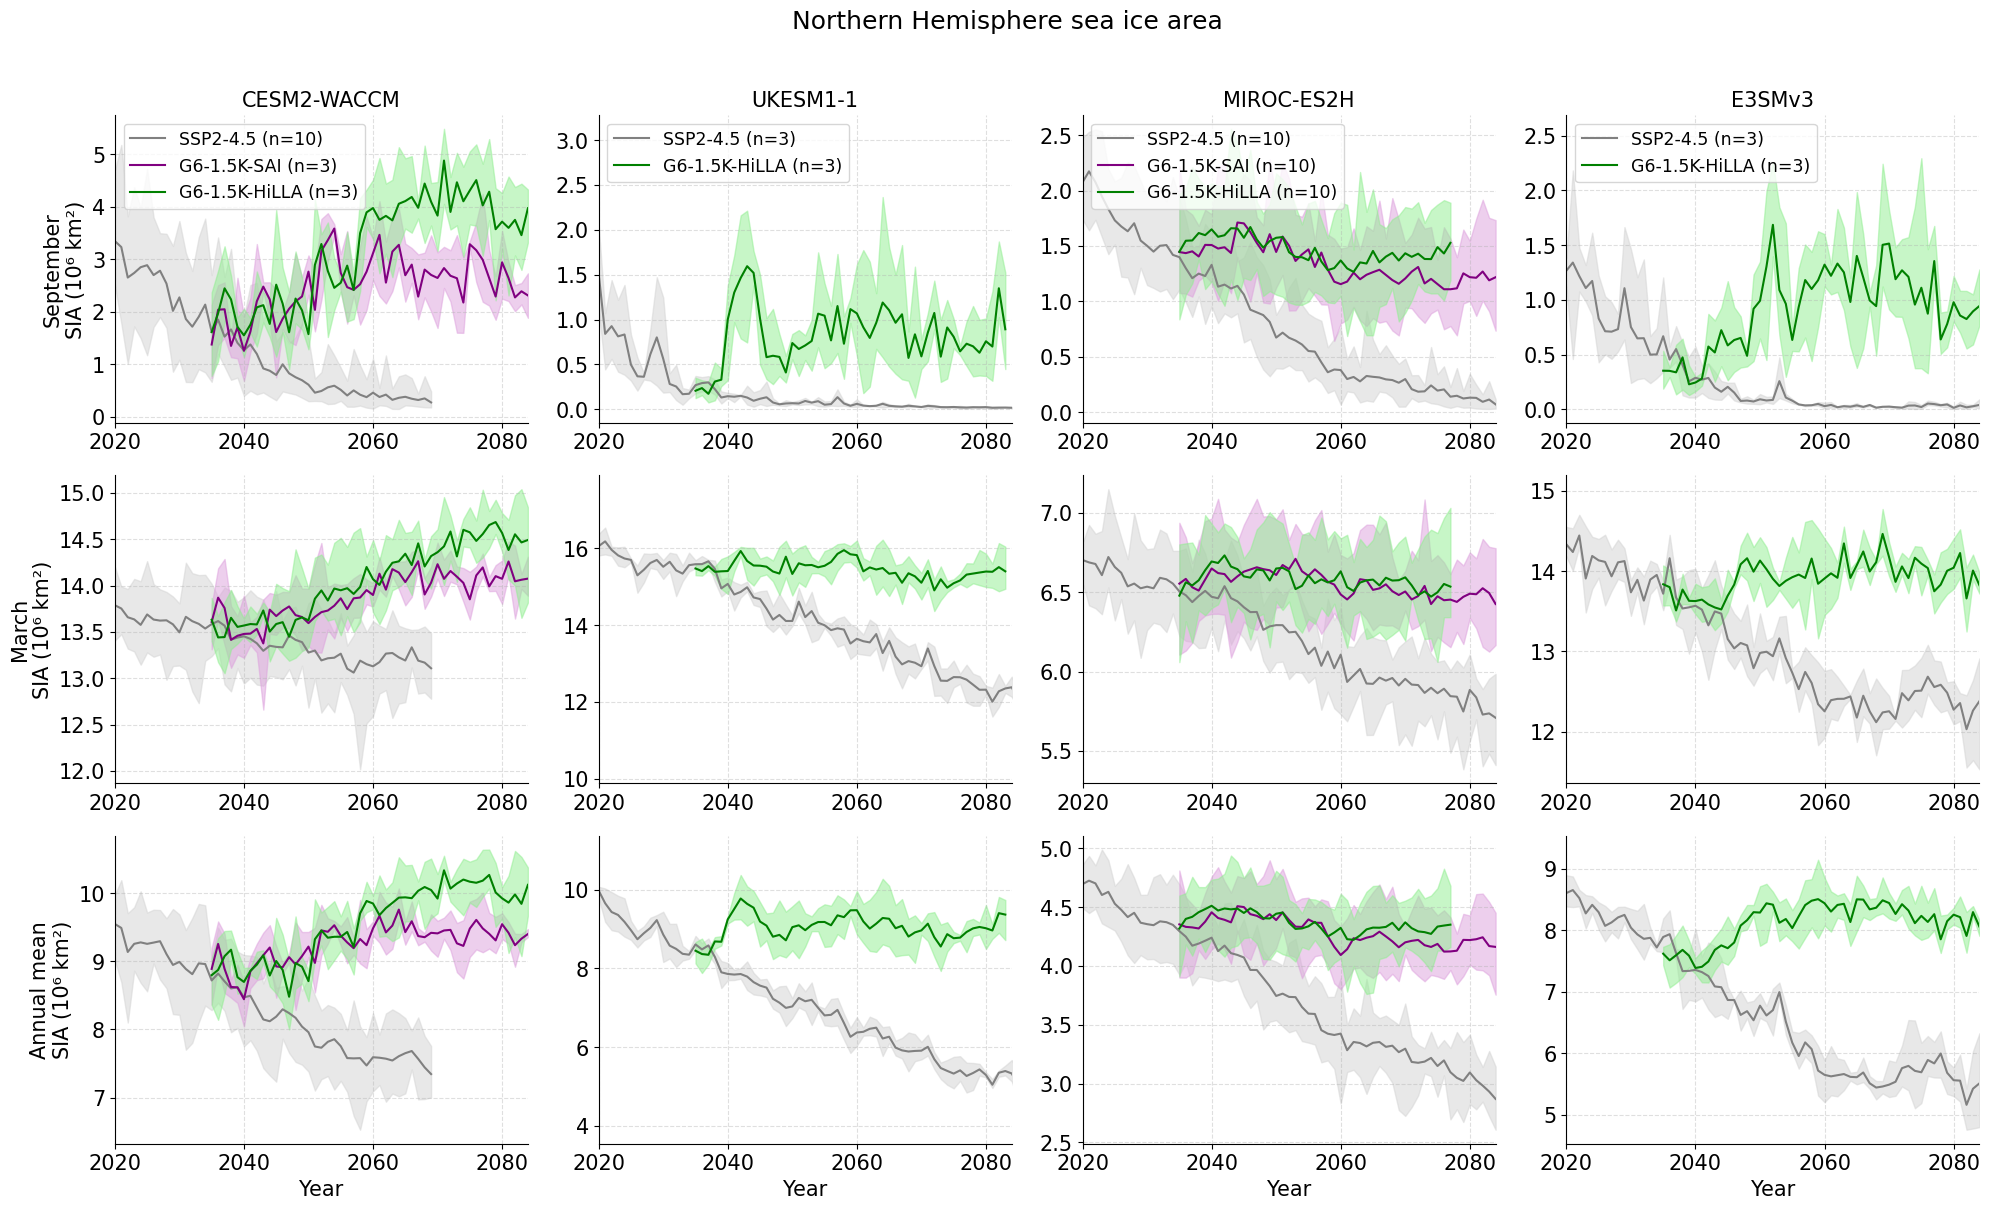

In [71]:
## Fig 1 — NH sea ice area timeseries
## Rows: September, March, Annual mean   Cols: CESM2-WACCM, UKESM1-1, MIROC-ES2H, E3SMv3

season_labels = ['September', 'March', 'Annual mean']
sia_dicts     = [sep_sia_dict, mar_sia_dict, ann_sia_dict]

fig, axs = plt.subplots(3, 4, figsize=(20, 12), sharey=False)

for row, (season, sia_d) in enumerate(zip(season_labels, sia_dicts)):
    for col, model in enumerate(models):
        ax = axs[row, col]
        for scenario, da_list in sia_d[model].items():
            n     = len(da_list)
            label = f'{scenario} (n={n})' if row == 0 else None
            ts    = xr.concat(da_list, dim='member', join='inner')
            years = ts.time.values
            ax.plot(years, ts.mean('member').values, c=colours[scenario], label=label)
            ax.fill_between(years, ts.min('member').values, ts.max('member').values,
                            color=colours[f'{scenario}_light'], alpha=0.5)

        if row == 0:
            ax.set_title(model, fontsize='medium')
            ax.legend(fontsize='small', loc='upper left')
        if col == 0:
            ax.set_ylabel(f'{season}\nSIA (10⁶ km²)')
        ax.set_xlabel('Year' if row == 2 else '')
        ax.set_xlim(2020, 2084)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(ls='--', alpha=0.4)

fig.suptitle('Northern Hemisphere sea ice area', fontsize='large', y=1.01)
plt.tight_layout()
plt.savefig('Figures/seaice_area_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()


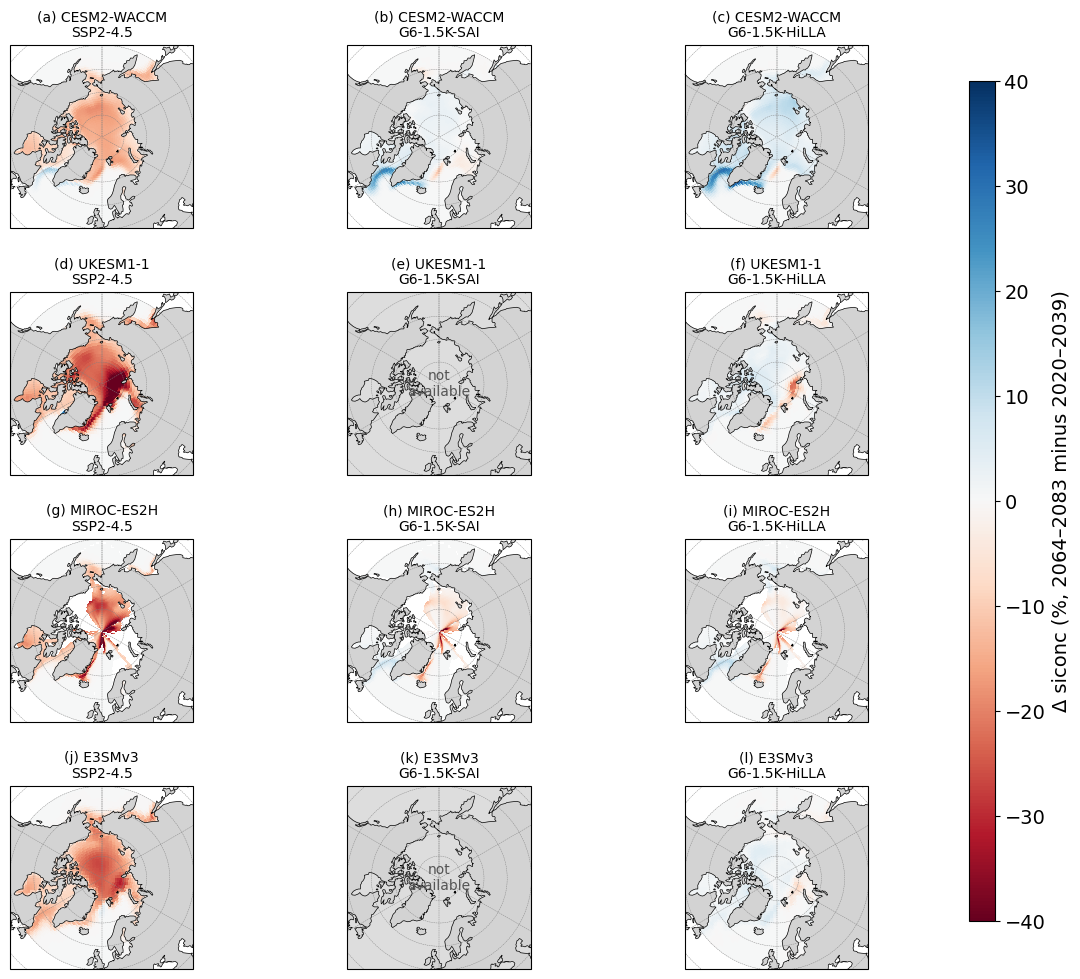

In [48]:
## Fig 2 — Arctic sea ice concentration anomaly maps (polar stereographic)
## Rows: models;  Cols: SSP2-4.5, G6-1.5K-SAI, G6-1.5K-HiLLA

scenarios = ['SSP2-4.5', 'G6-1.5K-SAI', 'G6-1.5K-HiLLA']
clim = 40   # colour scale ± %
cmap = 'RdBu'
proj = ccrs.NorthPolarStereo()

fig, axs = plt.subplots(4, 3, figsize=(13, 12),
                         subplot_kw={'projection': proj})

labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)', '(j)', '(k)', '(l)']
n = 0
for row, model in enumerate(models):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
        ax.coastlines(resolution='110m', linewidth=0.5, zorder=3)
        ax.gridlines(linewidth=0.3, linestyle='--', color='gray')

        if scenario in map_anom_dict[model]:
            da = map_anom_dict[model][scenario]
            lat_coord = 'latitude' if 'latitude' in da.coords else 'lat'
            lon_coord = 'longitude' if 'longitude' in da.coords else 'lon'
            da = da.sel(**{lat_coord: slice(50, 90)})
            pc = ax.pcolormesh(
                da[lon_coord].values, da[lat_coord].values, da.values,
                vmin=-clim, vmax=clim, cmap=cmap,
                transform=ccrs.PlateCarree(), zorder=1
            )
        else:
            ax.set_facecolor('#dddddd')
            ax.text(0.5, 0.5, 'not\navailable', transform=ax.transAxes,
                    ha='center', va='center', fontsize=10, color='#555555')

        ax.set_title(f'{labels[n]} {model}\n{scenario}', fontsize=10)
        n += 1

# shared colourbar
fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.1)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=-clim, vmax=clim))
fig.colorbar(sm, cax=cbar_ax, label='Δ siconc (%, 2064–2083 minus 2020–2039)')

plt.savefig('Figures/seaice_concentration_maps.png', dpi=200, bbox_inches='tight')
plt.show()

## Time of Emergence (ToE) — CESM2-WACCM and MIROC-ES2H NH sea ice area

For each window length `y` (years 2–35, starting from 2035) we fit a linear trend in NH SIA (Mkm² yr⁻¹) to each ensemble member.  
The SSP2-4.5 trend distribution gives a 5th–95th percentile band.  
**ToE** is the first `y` at which a HiLLA or SAI member's trend exceeds the SSP2-4.5 95th percentile — i.e. the geoengineering scenario is recovering sea ice faster than the upper bound of natural SSP2-4.5 variability.

Analysis is repeated for **September**, **March**, and the **annual mean**, and for both **CESM2-WACCM** (3 HiLLA/SAI members, 10 SSP2-4.5) and **MIROC-ES2H** (10 members each), shown as a 3-row × 2-column figure.


In [61]:
from scipy import stats

START_YEAR = 2035
Y_MIN, Y_MAX = 2, 30  # window lengths in years

y_vals = np.arange(Y_MIN, Y_MAX + 1)


def linear_trend(ts, year_start, n_years):
    """OLS linear trend (Mkm² yr⁻¹) over n_years starting at year_start."""
    da = ts.sel(time=slice(year_start, year_start + n_years - 1))
    if len(da) < n_years:
        return np.nan
    years = np.arange(year_start, year_start + n_years, dtype=float)
    slope, *_ = stats.linregress(years, da.values.astype(float))
    return slope


def compute_scenario_trends(ts_list):
    arr = np.full((len(y_vals), len(ts_list)), np.nan)
    for i, y in enumerate(y_vals):
        for j, ts in enumerate(ts_list):
            arr[i, j] = linear_trend(ts, START_YEAR, y)
    return arr


def find_toe(trend_arr, threshold, y_vals):
    """First y where each member's trend exceeds threshold; NaN if never."""
    toe = []
    for j in range(trend_arr.shape[1]):
        emerged = np.where(trend_arr[:, j] > threshold)[0]
        toe.append(float(y_vals[emerged[0]]) if len(emerged) > 0 else np.nan)
    return np.array(toe)


# Models and seasons to analyse
model_season_configs = {
    'CESM2-WACCM': [
        ('September',   sep_sia_dict['CESM2-WACCM']),
        ('March',       mar_sia_dict['CESM2-WACCM']),
        ('Annual mean', ann_sia_dict['CESM2-WACCM']),
    ],
    'MIROC-ES2H': [
        ('September',   sep_sia_dict['MIROC-ES2H']),
        ('March',       mar_sia_dict['MIROC-ES2H']),
        ('Annual mean', ann_sia_dict['MIROC-ES2H']),
    ],
}

# toe_results[model][season] = dict of trend arrays and ToE values
toe_results = {}
for model, season_list in model_season_configs.items():
    toe_results[model] = {}
    for season_label, sia_d in season_list:
        ssp245_trends = compute_scenario_trends(sia_d['SSP2-4.5'])
        hilla_trends  = compute_scenario_trends(sia_d['G6-1.5K-HiLLA'])
        sai_trends    = compute_scenario_trends(sia_d['G6-1.5K-SAI'])

        p05 = np.nanpercentile(ssp245_trends, 5,  axis=1)
        p95 = np.nanpercentile(ssp245_trends, 95, axis=1)

        hilla_toe = find_toe(hilla_trends, p95, y_vals)
        sai_toe   = find_toe(sai_trends,   p95, y_vals)

        toe_results[model][season_label] = dict(
            ssp245_trends=ssp245_trends, ssp245_p05=p05, ssp245_p95=p95,
            hilla_trends=hilla_trends,   sai_trends=sai_trends,
            hilla_toe=hilla_toe,         sai_toe=sai_toe,
        )
        print(f'{model:15s} {season_label:12s} — '
              f'HiLLA ToE: {hilla_toe}   SAI ToE: {sai_toe}')


CESM2-WACCM     September    — HiLLA ToE: [ 4. 11. 17.]   SAI ToE: [ 5.  3. 10.]
CESM2-WACCM     March        — HiLLA ToE: [ 9. 12.  4.]   SAI ToE: [10.  2. 13.]
CESM2-WACCM     Annual mean  — HiLLA ToE: [ 4.  4. 18.]   SAI ToE: [ 6. 18. 13.]
MIROC-ES2H      September    — HiLLA ToE: [ 4.  4.  2.  2.  4.  4. 22.  6. 21.  2.]   SAI ToE: [12.  2.  4. 18.  3.  4. 13.  9.  4.  7.]
MIROC-ES2H      March        — HiLLA ToE: [28.  3.  2. 22.  3.  5. 22.  3.  3.  2.]   SAI ToE: [ 3. 14.  4. 28.  3. 12. 21. 15.  6.  3.]
MIROC-ES2H      Annual mean  — HiLLA ToE: [13.  3.  2.  3.  4.  4. 21. 12.  7.  2.]   SAI ToE: [13.  8.  4. 21.  3. 10. 20. 10.  6.  6.]


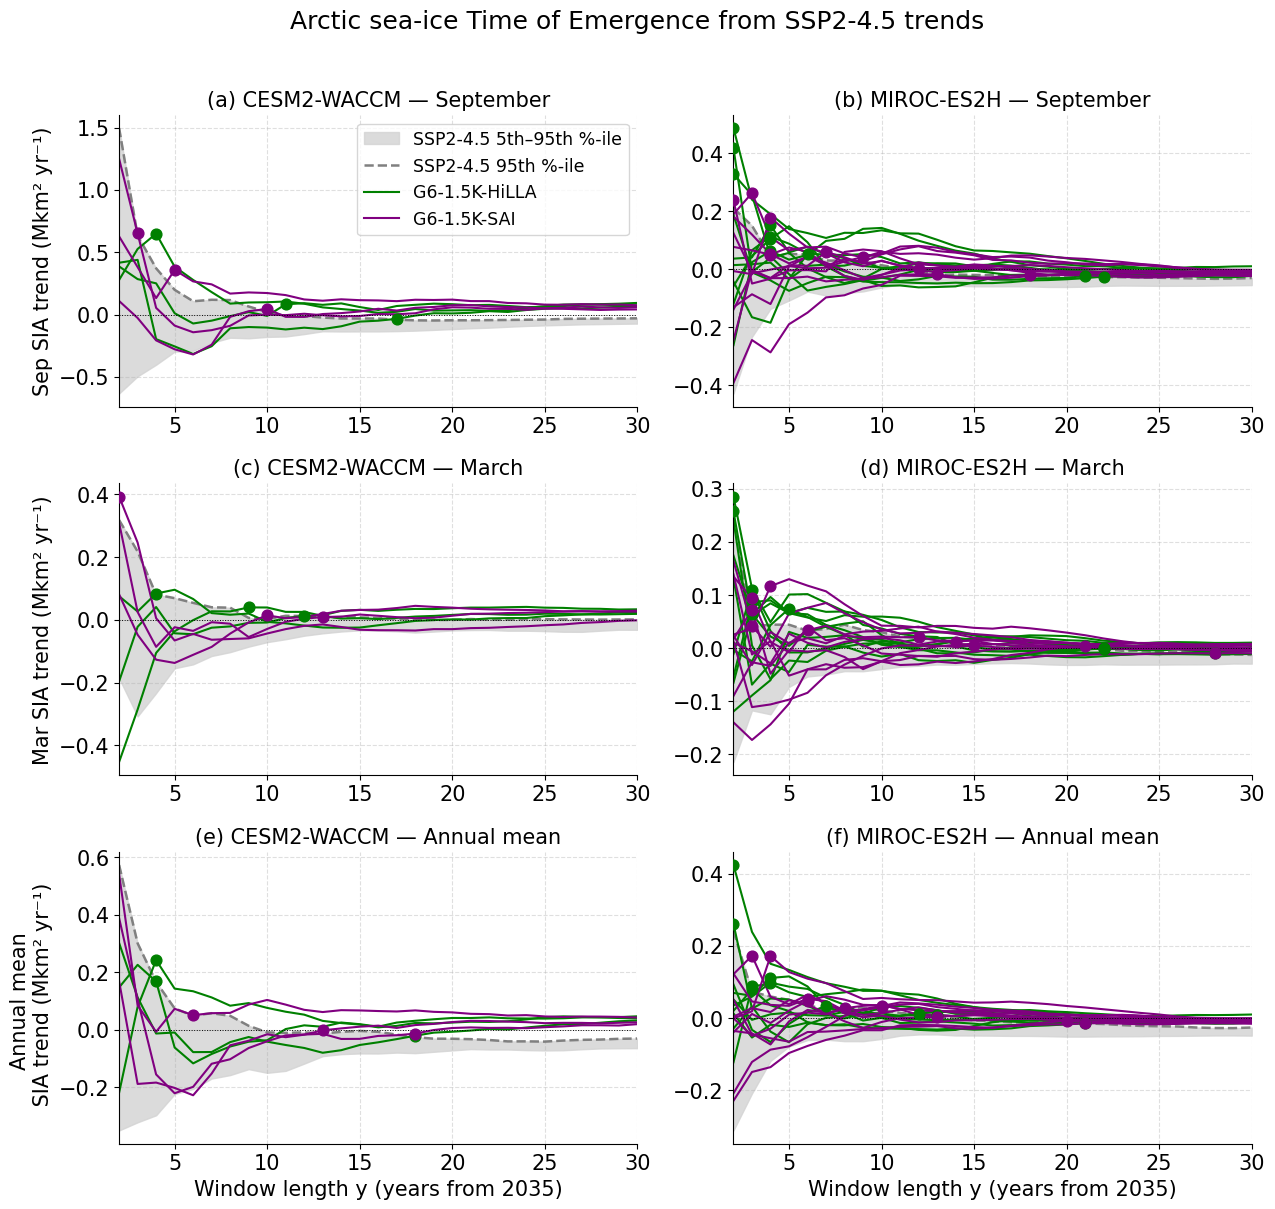

In [67]:
## Fig 3 — Time of Emergence: CESM2-WACCM and MIROC-ES2H SIA linear trends
## Rows: September | March | Annual mean     Cols: CESM2-WACCM | MIROC-ES2H

seasons = ['September', 'March', 'Annual mean']
model_list = ['CESM2-WACCM', 'MIROC-ES2H']

season_ylabels = {
    'September':   'Sep SIA trend (Mkm² yr⁻¹)',
    'March':       'Mar SIA trend (Mkm² yr⁻¹)',
    'Annual mean': 'Annual mean \n SIA trend (Mkm² yr⁻¹)',
}
panel_labels = [['(a)', '(b)'], ['(c)', '(d)'], ['(e)', '(f)']]

fig, axs = plt.subplots(3, 2, figsize=(13, 12), sharey=False)

for row, season in enumerate(seasons):
    for col, model in enumerate(model_list):
        ax  = axs[row, col]
        r   = toe_results[model][season]

        # SSP2-4.5 band
        ax.fill_between(y_vals, r['ssp245_p05'], r['ssp245_p95'],
                        color=colours['SSP2-4.5_light'], alpha=0.8,
                        label='SSP2-4.5 5th–95th %-ile')
        ax.plot(y_vals, r['ssp245_p95'], c=colours['SSP2-4.5'], lw=1.8, ls='--',
                label='SSP2-4.5 95th %-ile')

        # HiLLA members + ToE markers
        for j in range(r['hilla_trends'].shape[1]):
            ax.plot(y_vals, r['hilla_trends'][:, j],
                    c=colours['G6-1.5K-HiLLA'], lw=1.5,
                    label='G6-1.5K-HiLLA' if j == 0 else None)
            if not np.isnan(r['hilla_toe'][j]):
                idx = int(r['hilla_toe'][j]) - Y_MIN
                ax.scatter(r['hilla_toe'][j], r['hilla_trends'][idx, j],
                           c=colours['G6-1.5K-HiLLA'], s=60, zorder=5)

        # SAI members + ToE markers
        for j in range(r['sai_trends'].shape[1]):
            ax.plot(y_vals, r['sai_trends'][:, j],
                    c=colours['G6-1.5K-SAI'], lw=1.5,
                    label='G6-1.5K-SAI' if j == 0 else None)
            if not np.isnan(r['sai_toe'][j]):
                idx = int(r['sai_toe'][j]) - Y_MIN
                ax.scatter(r['sai_toe'][j], r['sai_trends'][idx, j],
                           c=colours['G6-1.5K-SAI'], s=60, zorder=5)

        ax.axhline(0, c='black', lw=0.7, ls=':')
        if col== 0:
            ax.set_ylabel(season_ylabels[season])
        ax.set_xlabel(f'Window length y (years from {START_YEAR})' if row == 2 else '')
        ax.set_title(f'{panel_labels[row][col]} {model} — {season}', fontsize='medium')
        #ax.legend(fontsize='small')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(ls='--', alpha=0.4)
        ax.set_xlim(Y_MIN, Y_MAX)

# single legend from top-left panel
axs[0, 0].legend(fontsize='small', loc='upper right')

fig.suptitle(
    'Arctic sea-ice Time of Emergence from SSP2-4.5 trends',
    fontsize='large', y=1.01
)
plt.tight_layout()
plt.savefig('Figures/seaice_ToE_3x2.png', dpi=200, bbox_inches='tight')
plt.show()


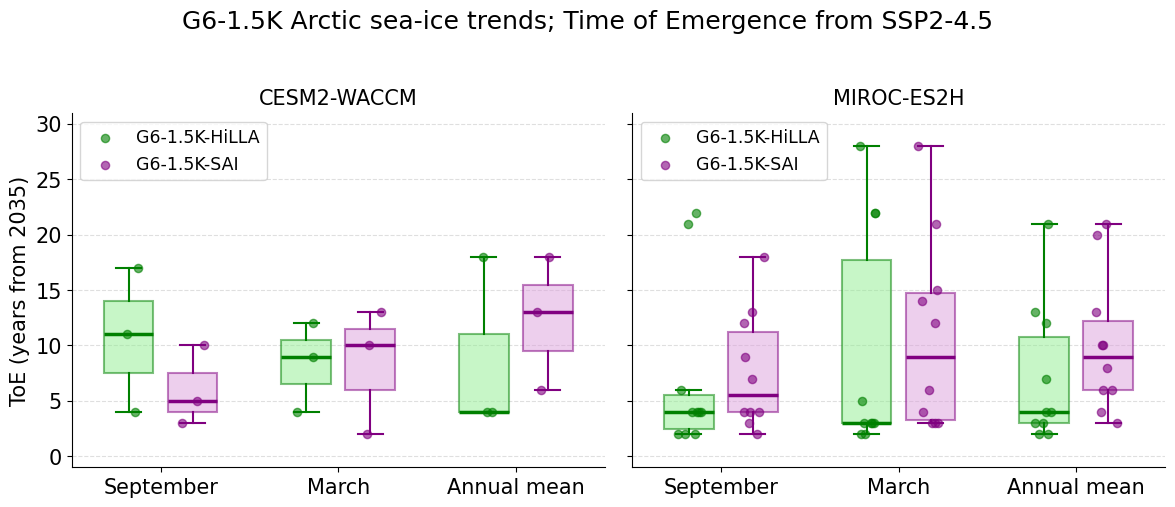

In [74]:
## Fig 4 — Box plot of ToE values: 2 panels (one per model)
## x-axis: season clusters (Sep, Mar, Annual mean)
## Two boxes per cluster: G6-1.5K-HiLLA (green) and G6-1.5K-SAI (purple)
## Jittered raw member values overlaid; members that never emerge shown as triangles at top

seasons    = ['September', 'March', 'Annual mean']
model_list = ['CESM2-WACCM', 'MIROC-ES2H']

x_pos  = np.arange(len(seasons))   # 0, 1, 2
offset = 0.18                       # left/right nudge for HiLLA vs SAI

scenario_style = [
    ('hilla_toe', 'G6-1.5K-HiLLA', -offset),
    ('sai_toe',   'G6-1.5K-SAI',   +offset),
]

rng = np.random.default_rng(42)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, model in zip(axs, model_list):
    y_max_emerged = Y_MIN  # track for placing "never emerged" markers

    for si, season in enumerate(seasons):
        r = toe_results[model][season]

        for toe_key, scenario, x_off in scenario_style:
            toe_arr = r[toe_key]
            col     = colours[scenario]
            col_lt  = colours[f'{scenario}_light']
            x       = si + x_off

            emerged     = toe_arr[~np.isnan(toe_arr)]
            n_total     = len(toe_arr)
            n_emerged   = len(emerged)
            n_never     = n_total - n_emerged

            if n_emerged > 0:
                ax.boxplot(
                    emerged,
                    positions=[x], widths=0.28,
                    patch_artist=True,
                    boxprops=dict(facecolor=col_lt, color=col, linewidth=1.5, alpha=0.5),
                    medianprops=dict(color=col, linewidth=2.5),
                    whiskerprops=dict(color=col, linewidth=1.5),
                    capprops=dict(color=col, linewidth=1.5),
                    flierprops=dict(marker='', color=col),
                    zorder=3,
                )
                y_max_emerged = max(y_max_emerged, emerged.max())

                # jittered scatter
                jitter = rng.uniform(-0.07, 0.07, size=n_emerged)
                ax.scatter(x + jitter, emerged,
                           c=col, s=35, zorder=5, alpha=0.6,
                           label=scenario if si == 0 else None)

            # annotate count of members that never emerged below the x-axis
            if n_never > 0:
                ax.text(x, Y_MIN - 1.5, f'{n_never}/{n_total}\nnever',
                        ha='center', va='top', fontsize='small', color=col)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(seasons)
    
    ax.set_title(model, fontsize='medium')
    ax.legend(fontsize='small', loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', ls='--', alpha=0.4)
    ax.set_xlim(-0.5, len(seasons) - 0.5)
    ax.set_ylim(Y_MIN - 3, Y_MAX + 1)

axs[0].set_ylabel('ToE (years from 2035)')

fig.suptitle('G6-1.5K Arctic sea-ice trends; Time of Emergence from SSP2-4.5', fontsize='large', y=1.02
)
plt.tight_layout()
plt.savefig('Figures/seaice_ToE_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()


In [75]:
# next step for the above - add UKESM's UKESM1.0 ssp245 ensemble, check it looks similar to 1.1, and then use that to add a third model above. 



But ... 

All the above assumes knowledge of the variability (by looking at trends across all 10 members of an ssp245 ensemble). What about the real-world case where we have one realisation of decline to consider, with obseravtions only since ~1980.

One thing that makes this different to other ToE lit is the knowledge of the start date. This makes me inclined to use the following method: 
estimate variability from de-trended sea-ice observations for prior N (=, e.g. 15 ?) years. This length of timeseries, N, to include for the variability estimate is a trade-off between statistical power and getting the background state correct, since varibaility changes with the amount of sea-ice. Need to test sensitivity of output estimates on this choice of N. 

Do a t-test on set of area values for Y years starting from 2035, for the SSP2-4.5 single member and the SAI single member. ToE defined as the number of years, Y, for which we have 95% confidence the two distributions have unequal means. Variance is assumed equal to that under the SSP2-4.5 run for the prior N years. 

While we will include only one member to calcualte the variability, and only one member for SAI **at a time**, we can repeat this process 3 times (or more, using the extra SSP2-4.5 members?) for CESM, UKESM, and E3SM, and 10x for MIROC
